In [6]:
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget

fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(12,4))

fit_params = [0.0, 0.005, 3, [1.8, 1.8], 0.90, 1.0, np.linspace(5,18,200)]
pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 

count = 0
for sig, ls, fillcolor in zip([0.7,0.5,0.2,0.0],['solid','dashed','dotted', 'dashdot'],['purple', 'blue', 'teal', 'orange']):
    qlf = QLF(1, fit_params[1])
    qlf.get_dNdlnMstar(sig)
    slopes = qlf.get_slope(qlf.get_Mhalo(qlf.StellBins))

    qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
    qlf.get_dNdlnL(fit_params[-1], fit_params[3])
    
    
    halos = qlf.get_Mhalo(qlf.StellBins)

    if sig == 0:
        ax.plot(10**halos, 10**qlf.StellBins, c='k', lw = 1)
    ax.set_xlabel('$M_h(M_\odot)$',fontsize=12)
    ax.set_ylabel('$M_*(M_\odot)$',fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim([10**7,10**12])
    ax.set_xlim([10**10, 10**15])
    if count == 0:
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax.axhline(10**mass, ls = 'dotted', c=c)
            ax.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)   
    if sig != 0:
        ax.fill_between(10**halos, np.e**(np.log(10**qlf.StellBins)-sig), np.e**(np.log(10**qlf.StellBins)+sig), color=fillcolor, label='$\sigma_{\lnM_*} = $'+str(sig), alpha=1)
    
#     stells = qlf.get_Mstar(qlf.HaloBins)
#     if sig == 0:
#         ax.plot(10**qlf.HaloBins, 10**stells, c='k', lw = 1)
#     ax.set_xlabel('$M_h(M_\odot)$',fontsize=12)
#     ax.set_ylabel('$M_*(M_\odot)$',fontsize=12)
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.set_ylim([10**7,10**12])
#     ax.set_xlim([10**10, 10**15])
#     if count == 0:
#         for c, mass in zip(cs, [7,8,9,10,11,12,13]):
#             ax.axhline(10**mass, ls = 'dotted', c=c)
#             ax.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)   
#     if sig != 0:
#         ax.fill_between(10**qlf.HaloBins, np.e**(np.log(10**stells)-sig), np.e**(np.log(10**stells)+sig), color=fillcolor, label='$\sigma_{\lnM_*} = $'+str(sig), alpha=1)
    
    
    if sig == 0:
        ax2.plot(10**qlf.StellBins, slopes, c='k', lw=1)
    ax2.set_ylabel('d$\lnM_* / $d$\lnM_h$')
    ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
    ax2.set_xscale('log')
    ax2.set_ylim([0,2.5])
    ax2.set_xlim([10**7, 10**12])
    ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
    if count == 0:
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax2.axvline(10**mass, ls = 'dotted', c=c)
            ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label='$10^{'+f'{mass}'+r'}< M_* (M_\odot) < 10^{'+f'{mass+1}'+'}$')
            ax2.legend(fontsize = 8, framealpha = 1)
    if sig != 0:
        ax2.fill_betweenx(slopes, np.e**(np.log(10**qlf.StellBins)-sig), np.e**(np.log(10**qlf.StellBins)+sig), color=fillcolor, alpha = 1)



    ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k', label='$\sigma_{\lnM_*} = $'+str(sig), ls=ls, lw = 1)
    ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
    ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
    ax3.set_xscale('log')
    ax3.set_xlim([10**7,10**12])
    ax3.set_ylim([-7,0])
    ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
    if count == 0:
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax3.axvline(10**mass, ls = 'dotted', c=c)
            ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    count += 1
    
ax3.legend(fontsize = 8)
ax.legend(fontsize = 8)
plt.tight_layout()

plt.savefig('plots/exploreSMFscatter.pdf', transparent = True)


FigureCanvasNbAgg()

In [2]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget
import glob as glob

files = np.array(glob.glob('umachine-dr1/observational_constraints/*.smf'))
zlow = np.array([float(f.split('_z')[1]) for f in files])
zhigh = np.array([float(f.split('_z')[2].split('.s')[0]) for f in files])
inds = np.where((zlow <= 1.0) & (zhigh >= 1.0))[0]
print(len(inds),'SMF files found within redshift range:')
for f in files[inds]:
    print(f)
smf_masses_tot = []
smf_tot = []
smf_errdown_tot = []
smf_errup_tot = []
for f in files[inds]:
    data = np.loadtxt(f)
    masses = (data[:,0] + data[:,1]) / 2.
    smf = data[:,2]
    smf_errdown = data[:,3]
    smf_errup = data[:,4]
    smf_masses_tot.extend(list(masses))
    smf_tot.extend(list(smf))
    smf_errdown_tot.extend(list(smf_errdown))
    smf_errup_tot.extend(list(smf_errup))
    
    
files = np.array(glob.glob('umachine-dr1/observational_constraints/*.ssfr'))
zlow = np.array([float(f.split('_z')[1]) for f in files])
zhigh = np.array([float(f.split('_z')[2].split('.s')[0]) for f in files])
inds = np.where((zlow <= 1.0) & (zhigh >= 1.0))[0]
print(len(inds),'SSFR files found within redshift range:')
for f in files[inds]:
    print(f)
ssfr_masses_tot = []
ssfr_tot = []
ssfr_errdown_tot = []
ssfr_errup_tot = []
for f in files[inds]:
    data = np.loadtxt(f)
    masses = (data[:,0] + data[:,1]) / 2.
    ssfr = data[:,2]
    ssfr_errdown = 10**ssfr - 10**(ssfr - data[:,3])
    ssfr_errup = 10**(ssfr + data[:,4]) - 10**ssfr
    ssfr_masses_tot.extend(list(masses))
    ssfr_tot.extend(list(ssfr))
    ssfr_errdown_tot.extend(list(ssfr_errdown))
    ssfr_errup_tot.extend(list(ssfr_errup))
    
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(11,4))

fit_params = [0.2, 0.005, 3, [1.8, 1.8], 0.90, 1.0, np.linspace(5,18,200)]

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 

qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax1.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax1.errorbar(10**np.array(ssfr_masses_tot), 10**np.array(ssfr_tot), yerr = [np.array(ssfr_errdown_tot), np.array(ssfr_errup_tot)], fmt = '.', c = 'r', markersize=5)
ax1.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax1.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim([10**7,10**12])
ax1.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax1.axvline(10**mass, ls = 'dotted', c=c)
    ax1.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax1.legend(fontsize = 8, framealpha = 1)



ax2.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
ax2.errorbar(10**np.array(smf_masses_tot), np.array(smf_tot), yerr = [np.array(smf_errdown_tot), np.array(smf_errup_tot)], fmt = '.', c = 'r', markersize=5)
ax2.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_xlim([10**7,10**12])
ax2.set_ylim([-8,-1])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.tight_layout()

# plt.savefig('plots/SMFvsObs.pdf', transparent = True)

# print(qlf.StellBins[-1] - qlf.StellBins[-2])
# lnStellBins = np.log(10**qlf.StellBins)
# print(lnStellBins[-1] - lnStellBins[-2])
# print(lnStellBins[1] - lnStellBins[0])
# print(qlf.StellBins[1] - qlf.StellBins[0])



5 SMF files found within redshift range:
umachine-dr1/observational_constraints/moustakas_z0.80_z1.00.smf
umachine-dr1/observational_constraints/tomczak_z0.75_z1.0.smf
umachine-dr1/observational_constraints/muzzin_ilbert_z0.5_z1.1.smf
umachine-dr1/observational_constraints/muzzin_ilbert_z1.0_z1.5.smf
umachine-dr1/observational_constraints/tomczak_z1.0_z1.25.smf
11 SSFR files found within redshift range:
umachine-dr1/observational_constraints/kajisawa09_z1.0_z1.5.ssfr
umachine-dr1/observational_constraints/whitaker14_z1.0_z1.5.ssfr
umachine-dr1/observational_constraints/karim11_z0.8_z1.0.ssfr
umachine-dr1/observational_constraints/tomczak15_z1.00_z1.25.ssfr
umachine-dr1/observational_constraints/zwart14_z0.5_z1.0.ssfr
umachine-dr1/observational_constraints/zwart14_z1.0_z1.5.ssfr
umachine-dr1/observational_constraints/karim11_z1.0_z1.2.ssfr
umachine-dr1/observational_constraints/schreiber15_z0.7_z1.2.ssfr
umachine-dr1/observational_constraints/tomczak15_z0.75_z1.00.ssfr
umachine-dr1/obse

FigureCanvasNbAgg()

In [3]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.2, color = c, linestyle='dotted')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)

        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
#     ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
    

f = h5py.File("output/chi2_SHEN_r100_v2.3.2_w0_s2.h5py", "r") 
siglnX2 = f['siglnX2'][:]
chi23d = f['z=1.0/chi23d_grid'][:]
f.close()
minval = np.min(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[0][0]]

print('\nShen best fits (linear SMBH relation): minval =',minval)
print(f'Best post-disk = {bestpost:.2f}')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, 3, [1.8, bestpost], 0.90, 1.0, np.linspace(5,18,200)]

ax.text(10**48.75, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:3])
QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.tight_layout()



# plt.savefig('plots/SMFstart_bestfit-linearSMBH-extendedL.pdf', transparent = True)



OSError: Unable to open file (unable to open file: name = 'output/chi2_SHEN_r100_v2.3.2_w0_s2.h5py', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [34]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw


f = h5py.File("output/chi2_SHEN_r30_v2.4.1_w0_s2.h5py", "r") 
siglnX2 = f['siglnX2'][:]
norm_locals = np.linspace(6, 10, 30)
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[1][0]]
bestnorm = norm_locals[minind[0][0]]


print('\nShen best fits (linear SMBH relation): minval =',minval)
print(f'Best post-disk = {bestpost:.2f},    Best local-norm = {bestnorm:.2f}')

fig, (ax, ax4) = plt.subplots(1,2,figsize=(7.5,3.5))
ax.text(10**48.75, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:3])
pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 
z=1
for n, color in zip([7,8,9],['yellow','orange','red']):
    fit_params = [0.2, 0.005, 3, [1.8, bestpost], 0.90, 1.0, np.linspace(5,18,200)]

    qlf = QLF(1, fit_params[1])
    qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True, norm_local = n)
    qlf.get_dNdlnL(fit_params[-1], fit_params[3])
    
    lumsp = 10**fit_params[-1]*3.8e33
    ax.plot(lumsp, np.log10(qlf.dNdlogL), c=color, label='$M_*/M_{BH} = 10^'+str(11-n)+'$')
    ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = color, label='$M_*/M_{BH} = 10^'+str(11-n)+'$')

    

lumsshen = fit_params[-1]
xshen = 10**lumsshen*3.8e33

dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')

ax.plot(xshen, dens, label='Shen Global A',c='k',lw=2,alpha = 0.5)
ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='gray', alpha=.2)

ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
#     ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')

### formatting and save
ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in') 
    
    
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'k', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
ax4.legend(fontsize = 8, framealpha=1)
ax.legend(fontsize = 8, loc='lower left')

plt.tight_layout()

plt.savefig('plots/SMFstart_postNorm-effects.pdf', transparent = True)




Shen best fits (linear SMBH relation): minval = 16.61707114724272
Best post-disk = 2.24,    Best local-norm = 7.93


FigureCanvasNbAgg()

In [35]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True, norm_local = None):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    if norm_local:
        qlf.get_Mbh(start, slope, norm, approx_local=approx_local, norm_local = norm_local)
    else:
        qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.2, color = c, linestyle='dotted')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)

        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
#     ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
    

f = h5py.File("output/chi2_SHEN_r30_v2.4.1_w0_s2.h5py", "r") 
siglnX2 = f['siglnX2'][:]
norm_locals = np.linspace(6, 10, 30)
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[1][0]]
bestnorm = norm_locals[minind[0][0]]


print('\nShen best fits (linear SMBH relation): minval =',minval)
print(f'Best post-disk = {bestpost:.2f},    Best local-norm = {bestnorm:.2f}')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, 3, [1.8, bestpost], 0.90, 1.0, np.linspace(5,18,200)]

ax.text(10**48.75, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:3])
QLFwShen_test(z=1, fit_params=fit_params, approx_local = True, norm_local = bestnorm)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True, norm_local = bestnorm)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.tight_layout()



# plt.savefig('plots/SMFstart_bestfit-linearSMBH-freepostNorm.pdf', transparent = True)




Shen best fits (linear SMBH relation): minval = 16.61707114724272
Best post-disk = 2.24,    Best local-norm = 7.93


FigureCanvasNbAgg()

# Plotting 6 panel QLF with best fit values from a chi2 output. (6 params)

In [8]:
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True, norm_local = 8.2):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local, norm_local = norm_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.5, color = c, linestyle='dotted')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    

In [95]:
f = h5py.File("output/chi2_SHEN_r10_v2.5.1_w3.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
norm_of_local = f['norm_of_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[1][0]]
bestslope = slope_low[minind[2][0]]
bestpost = siglnX2[minind[3][0]]
bestpre = siglnX1[minind[4][0]]
bestcrit = logMstar0[minind[5][0]]
bestlocal = norm_of_local[minind[0][0]]

print('\nShen best fits: minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f},   Best local norm = {bestlocal:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True, norm_local = 11+bestlocal)

ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
ax.text(10**43.8,-2.3, r'min($\chi^2$) = '+f'{minval:.2f}', fontsize = 10)

pfs = 8
ax4.text(10**7.2, 10**8.2, '$M_{*crit} = 10^{'+f'{bestcrit:.2f}'+'} M_\odot$', fontsize = pfs)
ax4.text(10**7.2, 10**7.7, '$\sigma_{pre\ \ln X} = $'+f'{bestpre:.2f}', fontsize = pfs)
ax4.text(10**7.2, 10**7.2, '$\sigma_{post\ \ln X} = $'+f'{bestpost:.2f}', fontsize = pfs)
ax4.text(10**10.2, 10**5.2, r'$\frac{d\ln M_{BH}}{d\ln M_*} = $'+f'{bestslope:.3f}', fontsize = pfs)
ax4.text(10**10.2, 10**4.7, r'$M_{BHnorm} = 10^{'+f'{bestnorm:.2f}'+'} M_\odot$', fontsize = pfs)
ax4.text(10**10.2, 10**4.2, r'post $\frac{M_{BH}}{M_*} = $'+f'{10**bestlocal:.4f}', fontsize = pfs)




pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True, norm_local = 11+bestlocal)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.suptitle('6 Param SHEN Best Fit')
plt.tight_layout()

plt.savefig('plots/bestfit_plots/QLF_6param-SHEN-r10-oL.pdf', transparent = True)




Shen best fits: minval = 9.383361875054025
Best crit = 10.00,  Best pre-disk = 2.56, Best post-disk = 1.78,  Best slope = 0.01,  Best norm = 2.00,   Best local norm = -2.77
 


FigureCanvasNbAgg()

# (5 params)

In [16]:
plt.close('all')
f = h5py.File("output/chi2_SHEN_r15_v2.2.1_w3.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()

for index, value in np.ndenumerate(chi23d):
    if siglnX2[index[2]] > siglnX1[index[3]]:
        chi23d[index] = 1e10

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits: minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
ax.text(10**43.8,-2.3, r'min($\chi^2$) = '+f'{minval:.2f}', fontsize = 10)

pfs = 8
ax4.text(10**7.2, 10**8.2, '$M_{*crit} = 10^{'+f'{bestcrit:.2f}'+'} M_\odot$', fontsize = pfs)
ax4.text(10**7.2, 10**7.7, '$\sigma_{pre\ \ln X} = $'+f'{bestpre:.2f}', fontsize = pfs)
ax4.text(10**7.2, 10**7.2, '$\sigma_{post\ \ln X} = $'+f'{bestpost:.2f}', fontsize = pfs)
ax4.text(10**10.2, 10**5.2, r'$\frac{d\ln M_{BH}}{d\ln M_*} = $'+f'{bestslope:.3f}', fontsize = pfs)
ax4.text(10**10.2, 10**4.7, r'$M_{BHnorm} = 10^{'+f'{bestnorm:.2f}'+'} M_\odot$', fontsize = pfs)


pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.suptitle('5 Param SHEN Best Fit')
plt.tight_layout()

plt.savefig('plots/bestfit_plots/QLF_5param-SHEN-r15-oL.pdf', transparent = True)




Shen best fits: minval = 10.138410054196413
Best crit = 10.89,  Best pre-disk = 2.29, Best post-disk = 1.64,  Best slope = 1.50,  Best norm = 0.21
 


FigureCanvasNbAgg()

In [17]:
# plt.close('all')
f = h5py.File("output/chi2_SHEN_r15_v2.2.2_w3.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()

for index, value in np.ndenumerate(chi23d):
    if siglnX2[index[2]] > siglnX1[index[3]]:
        chi23d[index] = 1e10

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits: minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
ax.text(10**43.8,-2.3, r'min($\chi^2$) = '+f'{minval:.2f}', fontsize = 10)

pfs = 8
ax4.text(10**7.2, 10**8.2, '$M_{*crit} = 10^{'+f'{bestcrit:.2f}'+'} M_\odot$', fontsize = pfs)
ax4.text(10**7.2, 10**7.7, '$\sigma_{pre\ \ln X} = $'+f'{bestpre:.2f}', fontsize = pfs)
ax4.text(10**7.2, 10**7.2, '$\sigma_{post\ \ln X} = $'+f'{bestpost:.2f}', fontsize = pfs)
ax4.text(10**10.2, 10**5.2, r'$\frac{d\ln M_{BH}}{d\ln M_*} = $'+f'{bestslope:.3f}', fontsize = pfs)
ax4.text(10**10.2, 10**4.7, r'$M_{BHnorm} = 10^{'+f'{bestnorm:.2f}'+'} M_\odot$', fontsize = pfs)


pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.suptitle('5 Param SHEN Best Fit')
plt.tight_layout()

plt.savefig('plots/bestfit_plots/QLF_5param-SHEN-r15-eL.pdf', transparent = True)




Shen best fits: minval = 8.745871943937821
Best crit = 10.89,  Best pre-disk = 2.29, Best post-disk = 1.64,  Best slope = 1.39,  Best norm = 0.21
 


FigureCanvasNbAgg()

# (2 params)

In [88]:
# plt.close('all')
f = h5py.File("output/chi2_SHEN_r15_v2.4.1_w3_s2.h5py", "r") 
siglnX2 = f['siglnX2'][:]
norm_of_local = f['norm_of_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[1][0]]
bestlocal = norm_of_local[minind[0][0]]

print('\nShen best fits: minval =',minval)
print(f'Best post-disk = {bestpost:.2f},  Best local norm = {bestlocal:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, 3, [2, bestpost], 1, 0, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True, norm_local = 11+bestlocal)

ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
ax.text(10**43.8,-2.3, r'min($\chi^2$) = '+f'{minval:.2f}', fontsize = 10)

pfs = 8
ax4.text(10**7.2, 10**7.2, '$\sigma_{post\ \ln X} = $'+f'{bestpost:.2f}', fontsize = pfs)
ax4.text(10**10.2, 10**4.2, r'post $\frac{M_{BH}}{M_*} = $'+f'{10**bestlocal:.4f}', fontsize = pfs)



pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True, norm_local = 11+bestlocal)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.suptitle('5 Param SHEN Best Fit')
plt.tight_layout()

plt.savefig('plots/bestfit_plots/QLF_2param-SHEN-r15-oL.pdf', transparent = True)




Shen best fits: minval = 25.227482379558836
Best post-disk = 2.00,  Best local norm = -2.80
 


FigureCanvasNbAgg()

In [73]:
# plt.close('all')
f = h5py.File("output/chi2_SHEN_r15_v2.4.2_w3_s2.h5py", "r") 
siglnX2 = f['siglnX2'][:]
norm_of_local = f['norm_of_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[1][0]]
bestlocal = norm_of_local[minind[0][0]]

print('\nShen best fits: minval =',minval)
print(f'Best post-disk = {bestpost:.2f},  Best local norm = {bestlocal:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, 3, [2, bestpost], 1, 0, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
ax.text(10**43.8,-2.3, r'min($\chi^2$) = '+f'{minval:.2f}', fontsize = 10)

pfs = 8
ax4.text(10**7.2, 10**7.2, '$\sigma_{post\ \ln X} = $'+f'{bestpost:.2f}', fontsize = pfs)
ax4.text(10**10.2, 10**4.2, r'post $\frac{M_{BH}}{M_*} = $'+f'{10**bestlocal:.4f}', fontsize = pfs)



pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True, norm_local = 11+bestlocal)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.suptitle('5 Param SHEN Best Fit')
plt.tight_layout()

plt.savefig('plots/bestfit_plots/QLF_2param-SHEN-eL.pdf', transparent = True)




Shen best fits: minval = 24.92192204321438
Best post-disk = 2.00,  Best local norm = -2.80
 


FigureCanvasNbAgg()

# Best fit corner plots for QLF fit.



### 5-param no restrictions



In [26]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np

def CHI2_SHEN_5param(z, FILE = "output/chi2_SHEN_r15_v2.2.2_w3.h5py"):

    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[0.01,1.5,5,12.5],[0,3,5,12.5],[0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        for index, value in np.ndenumerate(chi23d):
            if siglnX2[index[2]] > siglnX1[index[3]]:
                chi23d[index] = 1e10

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]
        chi23d[chi23d == 1e10] = np.nan
        
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:,minind[3][0],minind[4][0]].T
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:,minind[3][0],minind[4][0]].T          
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[minind[0][0],minind[1][0],:,minind[3][0],:]           
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            grid2d = chi23d[minind[0][0],minind[1][0],:,:,minind[4][0]]           
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            grid2d = chi23d[minind[0][0],:,minind[2][0],:,minind[4][0]].T           
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            grid2d = chi23d[:,minind[1][0],minind[2][0],:,minind[4][0]].T            
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            grid2d = chi23d[minind[0][0],minind[1][0],minind[2][0],:,:]           
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            grid2d = chi23d[minind[0][0],:,minind[2][0],minind[3][0],:].T           
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            grid2d = chi23d[:,minind[1][0],minind[2][0],minind[3][0],:].T        
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:            
            grid2d = chi23d[:,:,minind[2][0],minind[3][0],minind[4][0]]           
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=400, alpha=0.85)
#         img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    plt.savefig('plots/bestfit_plots/Chi2_5param-SHEN-r15-eL.pdf')

    

CHI2_SHEN_5param(z=1.0)



FigureCanvasNbAgg()

Best crit = 10.89,  Best pre-disk = 2.29, Best post-disk = 1.64,  Best slope = 1.39,  Best norm = 0.21
 


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/colors.py:1031: RuntimeWarning: invalid value encountered in less_equal
  mask |= resdat <= 0


### 5-param pre_sig > post-sig restriction Bivariate



In [56]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np
plt.close('all')

def CHI2_SHEN_5param(z, FILE = "output/chi2_SHEN_r15_v2.2.2_w3.h5py"):

    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[0.01,1.5,5,12.5],[0,3,5,12.5],[0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        for index, value in np.ndenumerate(chi23d):
            if siglnX2[index[2]] > siglnX1[index[3]]:
                chi23d[index] = 1e10

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]        
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        reso = len(chi23d[:,0,0,0,0])
        chi2_proj = np.zeros((reso,reso))
        if sums[ind] == 0:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, j, :, :])
            grid2d = chi2_proj.T
#             grid2d = chi23d[minind[0][0],:,:,minind[3][0],minind[4][0]].T
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, j, :, :])
            grid2d = chi2_proj.T
#             grid2d = chi23d[:,minind[1][0],:,minind[3][0],minind[4][0]].T  
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, j])
            grid2d = chi2_proj
#             grid2d = chi23d[minind[0][0],minind[1][0],:,minind[3][0],:]  
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, j, :])
            grid2d = chi2_proj
#             grid2d = chi23d[minind[0][0],minind[1][0],:,:,minind[4][0]]           
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, j, :])
            grid2d = chi2_proj.T
#             grid2d = chi23d[minind[0][0],:,minind[2][0],:,minind[4][0]].T   
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, j, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX1<bestpost, :] = np.nan
#             grid2d = chi23d[:,minind[1][0],minind[2][0],:,minind[4][0]].T            
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, j])
            grid2d = chi2_proj
#             grid2d = chi23d[minind[0][0],minind[1][0],minind[2][0],:,:]  
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, j])
            grid2d = chi2_proj.T
#             grid2d = chi23d[minind[0][0],:,minind[2][0],minind[3][0],:].T           
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, j])
            grid2d = chi2_proj.T
#             grid2d = chi23d[:,minind[1][0],minind[2][0],minind[3][0],:].T        
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:  
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, j, :, :, :])
            grid2d = chi2_proj
#             grid2d = chi23d[:,:,minind[2][0],minind[3][0],minind[4][0]]           
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
        chi2_proj[chi2_proj == 1e10] = np.nan
#         norm = colors.LogNorm()
        vmax = 50
        norm = colors.Normalize(vmin = minval, vmax = vmax)
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,20,30,40,50], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    plt.savefig('plots/bestfit_plots/bivariate_5param-SHEN-r15-eL-sigristrict.pdf')

    

CHI2_SHEN_5param(z=1.0)



FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:1173: UserWarning: No contour levels were found within the data range.
  warnings.warn("No contour levels were found"


Best crit = 10.89,  Best pre-disk = 2.29, Best post-disk = 1.64,  Best slope = 1.39,  Best norm = 0.21
 


### 5-param no restriction Bivariate



In [52]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np
plt.close('all')

def CHI2_SHEN_5param(z, FILE = "output/chi2_SHEN_r15_v2.2.2_w3.h5py"):

    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[0.01,1.5,5,12.5],[0,3,5,12.5],[0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]        
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        reso = len(chi23d[:,0,0,0,0])
        chi2_proj = np.zeros((reso,reso))
        if sums[ind] == 0:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, j, :, :])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, j, :, :])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, j, :])
            grid2d = chi2_proj          
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, j, :])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, j, :])
            grid2d = chi2_proj.T           
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, j])
            grid2d = chi2_proj.T          
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:  
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, j, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
        chi2_proj[chi2_proj == 1e10] = np.nan
#         norm = colors.LogNorm()
        vmax = 50
        norm = colors.Normalize(vmin = minval, vmax = vmax)
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,20,30,40,50], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    plt.savefig('plots/bestfit_plots/bivariate_5param-SHEN-r15-eL-nosigrestrict.pdf')

    

CHI2_SHEN_5param(z=1.0)



FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:1173: UserWarning: No contour levels were found within the data range.
  warnings.warn("No contour levels were found"


Best crit = 10.36,  Best pre-disk = 1.64, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.71
 


### 5-param npre_sig < post_sig restriction Bivariate



In [54]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np
plt.close('all')

def CHI2_SHEN_5param(z, FILE = "output/chi2_SHEN_r15_v2.2.1_w3.h5py"):

    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],[0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[0.01,1.5,5,12.5],[0,3,5,12.5],[0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        for index, value in np.ndenumerate(chi23d):
            if siglnX2[index[2]] < siglnX1[index[3]]:
                chi23d[index] = 1e10

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]        
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        reso = len(chi23d[:,0,0,0,0])
        chi2_proj = np.zeros((reso,reso))
        if sums[ind] == 0:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, j, :, :])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, j, :, :])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, j, :])
            grid2d = chi2_proj          
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, j, :])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, j, :])
            grid2d = chi2_proj.T           
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, j])
            grid2d = chi2_proj.T          
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:  
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, j, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
        chi2_proj[chi2_proj == 1e10] = np.nan
#         norm = colors.LogNorm()
        vmax = 50
        norm = colors.Normalize(vmin = minval, vmax = vmax)
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,20,30,40,50], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)-20, color='gray', alpha=.3)
    plt.savefig('plots/bestfit_plots/bivariate_5param-SHEN-r15-oL-sigrestrict-op.pdf')

    

CHI2_SHEN_5param(z=1.0)



FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:1173: UserWarning: No contour levels were found within the data range.
  warnings.warn("No contour levels were found"


Best crit = 10.36,  Best pre-disk = 1.64, Best post-disk = 2.29,  Best slope = 0.44,  Best norm = 1.71
 


### 6-param npre_sig > post_sig restriction Bivariate



In [73]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np
plt.close('all')

def CHI2_SHEN_5param(z, FILE = "CHI2_SCRIPTS/output/chi2_SHEN_r10_v2.5.1_w3.h5py"):

    fig = plt.figure(figsize=(15,12))
    gs = gridspec.GridSpec(5, 5)
    
    f = h5py.File(FILE, "r") 
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    f.close()
                     
    axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
    axi = [4,4,4,4,4,3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [\
               [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
               [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
               [logMstar0[0], logMstar0[-1], norm_of_local[-1], norm_of_local[0]],\
               [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
               [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
               [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
              ]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    locall = r'$\log_{10}[\rmM_{\rm{BH}}/\rmM_*]$'
    xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
    ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,np.log10(0.001),np.log10(0.005)],[0,3,np.log10(0.001),np.log10(0.005)],[5,12.5,np.log10(0.001),np.log10(0.005)],[1,8,np.log10(0.001),np.log10(0.005)],[1,8,np.log10(0.001),np.log10(0.005)],\
             [0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],\
             [0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],\
             [0.01,1.5,5,12.5],[0,3,5,12.5],\
             [0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    localt = [-3, -2.8, -2.6, -2.4]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
    for ind, i, j in zip(range(15), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        for index, value in np.ndenumerate(chi23d):
            if siglnX2[index[3]] > siglnX1[index[4]]:
                chi23d[index] = 1e10

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestlocal = norm_of_local[minind[0][0]] 
        bestnorm = norm_from_local[minind[1][0]]
        bestslope = slope_low[minind[2][0]]
        bestpost = siglnX2[minind[3][0]]
        bestpre = siglnX1[minind[4][0]]
        bestcrit = logMstar0[minind[5][0]]     
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        reso = len(chi23d[:,0,0,0,0,0])
        chi2_proj = np.zeros((reso,reso))
        if sums[ind] == 0:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, j, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, j, :, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestnorm, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, :, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, j, :])
            grid2d = chi2_proj
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestpre, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, j, :, :])
            grid2d = chi2_proj
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestpost, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, j, :, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, j, :, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, :, j])
            grid2d = chi2_proj
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, j, :])
            grid2d = chi2_proj
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, j, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 10:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, j, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 11:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, :, i, j])
            grid2d = chi2_proj
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 12:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 13:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 14:  
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, j, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
        chi2_proj[chi2_proj == 1e10] = np.nan
        vmax = 50
        norm = colors.Normalize(vmin = minval, vmax = vmax)
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,20,30,40,50], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[10].get_xticklabels(), visible=False)
    plt.setp(axes_l[11].get_xticklabels(), visible=False)
    plt.setp(axes_l[12].get_xticklabels(), visible=False)
    plt.setp(axes_l[13].get_xticklabels(), visible=False)
    plt.setp(axes_l[14].get_xticklabels(), visible=False)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[7].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    plt.setp(axes_l[10].get_yticklabels(), visible=False)
    plt.setp(axes_l[11].get_yticklabels(), visible=False)
    plt.setp(axes_l[13].get_yticklabels(), visible=False)
    
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[8].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[8].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    plt.savefig('plots/bestfit_plots/bivariate_6param-SHEN-r10-oL-sigristrict.pdf')

    

CHI2_SHEN_5param(z=1.0)



FigureCanvasNbAgg()

0


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:1173: UserWarning: No contour levels were found within the data range.
  warnings.warn("No contour levels were found"


1
2
3
4
5
6
7
8
9
10
11
12
13
14
Best crit = 10.00,  Best pre-disk = 2.56, Best post-disk = 1.78,  Best slope = 0.01,  Best norm = 2.00
 


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:1173: UserWarning: No contour levels were found within the data range.
  warnings.warn("No contour levels were found"


Best crit = 12.00,  Best pre-disk = 2.50, Best post-disk = 1.00,  Best slope = 1.30,  Best norm = 0.50
 


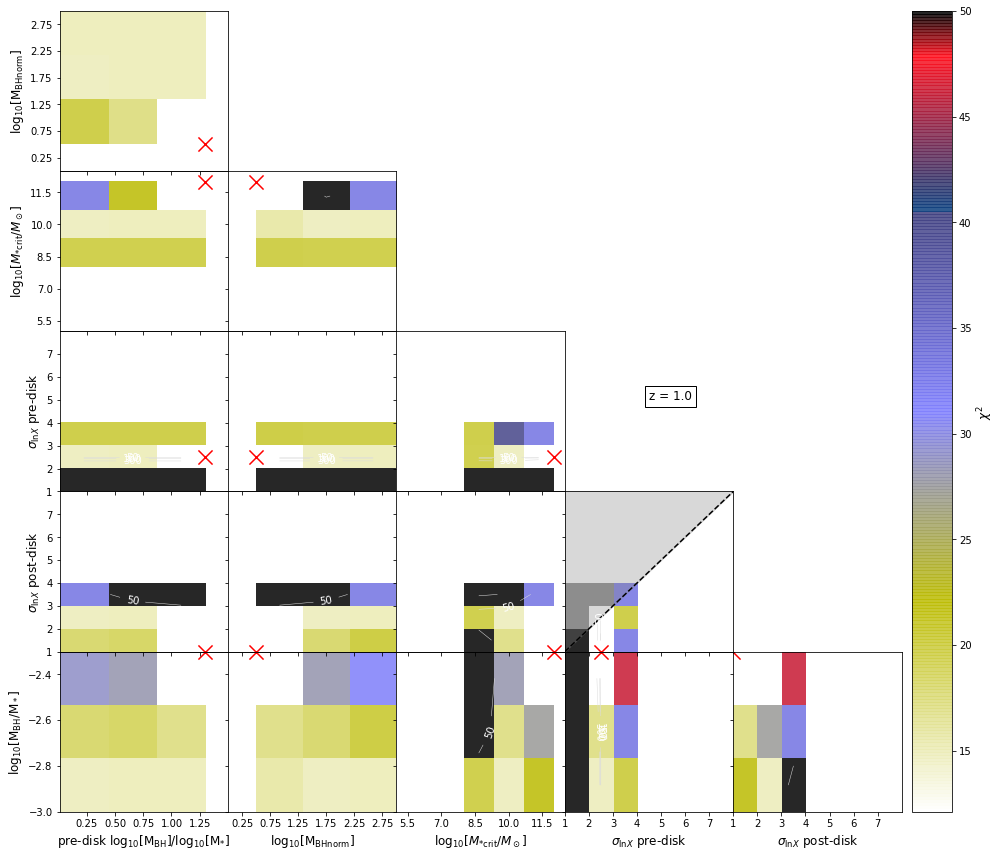

In [2]:
import matplotlib.ticker as ticker
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter
import h5py
import numpy as np
plt.close('all')

def CHI2_SHEN_5param(z, FILE = "QUEST/output/chi2_SHEN_r3_6param.h5py"):

    fig = plt.figure(figsize=(15,12))
    gs = gridspec.GridSpec(5, 5)
    
    f = h5py.File(FILE, "r") 
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    f.close()
                     
    axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
    axi = [4,4,4,4,4,3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [\
               [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
               [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
               [logMstar0[0], logMstar0[-1], norm_of_local[-1], norm_of_local[0]],\
               [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
               [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
               [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
              ]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    locall = r'$\log_{10}[\rmM_{\rm{BH}}/\rmM_*]$'
    xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
    ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0.01,1.5,np.log10(0.001),np.log10(0.005)],[0,3,np.log10(0.001),np.log10(0.005)],[5,12.5,np.log10(0.001),np.log10(0.005)],[1,8,np.log10(0.001),np.log10(0.005)],[1,8,np.log10(0.001),np.log10(0.005)],\
             [0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],[1,8,1,8],\
             [0.01,1.5,1,8],[0,3,1,8],[5,12.5,1,8],\
             [0.01,1.5,5,12.5],[0,3,5,12.5],\
             [0.01,1.5,0,3]]
    slopet = [0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
    localt = [-3, -2.8, -2.6, -2.4]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
    for ind, i, j in zip(range(15), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi2_grid'][:].T
        f.close()
        
        for index, value in np.ndenumerate(chi23d):
            if siglnX2[index[3]] > siglnX1[index[4]]:
                chi23d[index] = 1e10

        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestlocal = norm_of_local[minind[0][0]] 
        bestnorm = norm_from_local[minind[1][0]]
        bestslope = slope_low[minind[2][0]]
        bestpost = siglnX2[minind[3][0]]
        bestpre = siglnX1[minind[4][0]]
        bestcrit = logMstar0[minind[5][0]]     
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        reso = len(chi23d[:,0,0,0,0,0])
        chi2_proj = np.zeros((reso,reso))
        if sums[ind] == 0:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, j, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, j, :, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestnorm, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, :, j])
            grid2d = chi2_proj
            ax.scatter(bestcrit, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, :, j, :])
            grid2d = chi2_proj
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestpre, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[i, :, :, j, :, :])
            grid2d = chi2_proj
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestpost, bestlocal, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, j, :, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, j, :, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, :, j])
            grid2d = chi2_proj
#             grid2d[siglnX2>bestpre, :] = np.nan
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, i, j, :])
            grid2d = chi2_proj
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, j, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 10:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, j, :])
            grid2d = chi2_proj.T
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 11:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, :, :, i, j])
            grid2d = chi2_proj
#             grid2d[siglnX1<bestpost, :] = np.nan
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 12:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, :, i, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 13:
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, :, :, :, j])
            grid2d = chi2_proj.T
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 14:  
            for i in range(reso):
                for j in range(reso):
                    chi2_proj[i, j] = np.amin(chi23d[:, i, j, :, :, :])
            grid2d = chi2_proj
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
        chi2_proj[chi2_proj == 1e10] = np.nan
        vmax = 50
        norm = colors.Normalize(vmin = minval, vmax = vmax)
        
        cmap = matplotlib.cm.get_cmap('gist_stern_r')
        cmap.set_bad(color='gray')
        img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = vmax, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,20,30,40,50], ncolors = 220),linestyles='dashed')
    print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[10].get_xticklabels(), visible=False)
    plt.setp(axes_l[11].get_xticklabels(), visible=False)
    plt.setp(axes_l[12].get_xticklabels(), visible=False)
    plt.setp(axes_l[13].get_xticklabels(), visible=False)
    plt.setp(axes_l[14].get_xticklabels(), visible=False)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[7].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    plt.setp(axes_l[10].get_yticklabels(), visible=False)
    plt.setp(axes_l[11].get_yticklabels(), visible=False)
    plt.setp(axes_l[13].get_yticklabels(), visible=False)
    
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[8].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[8].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
#     plt.savefig('plots/bestfit_plots/bivariate_6param-SHEN-r10-oL-sigristrict.pdf')

    

CHI2_SHEN_5param(z=1.0)



# Animation with the 6 panel QLF.


In [45]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.5, color = c, linestyle='dotted')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
#     ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
f = h5py.File("output/chi2_SHEN_r10_v2.2.1_w3.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(15.5,3.5))

fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

# ax.text(10**48.75, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', label='Implemented')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'r', linestyle='dashed', label='~Local')
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**3, 10**10])
ax4.legend(fontsize = 8, framealpha=1)
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)

plt.tight_layout()

for s, n, m, sig in zip(slopes,norms,crits,sigs):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    info += '\n'+r'pre-disk $\sigma_{\ln X } = $ %.02f'%sig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m, sig)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-presig.gif', writer='PillowWriter', fps=2)

# plt.savefig('plots/QLF_bestfit_kneeLumweight.pdf', transparent = True)




Shen best fits (orig, stacked z): minval = 33.07906551655003
Best crit = 9.17,  Best pre-disk = 3.00, Best post-disk = 2.00,  Best slope = 0.01,  Best norm = 3.00
 


FigureCanvasNbAgg()

# $M_{*crit}$ scatter test.

In [5]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params, z, approx_local=True):
   

    ### what fit params are we using
    siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.5, color = c, linestyle='dotted')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
#     ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'QLF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$)', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    
f = h5py.File("output/chi2_SHEN_r10_v2.2.2_w0.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

fit_params = [0.2, 0.0005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]
siglnMcrit = 1.5

qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
qlf2 = QLF(1, fit_params[1])
qlf2.get_Mbh(fit_params[2]-siglnMcrit, fit_params[4], fit_params[5], approx_local=True)
qlf2.get_dNdlnL(fit_params[-1], fit_params[3])
qlf3 = QLF(1, fit_params[1])
qlf3.get_Mbh(fit_params[2]+siglnMcrit, fit_params[4], fit_params[5], approx_local=True)
qlf3.get_dNdlnL(fit_params[-1], fit_params[3])

CRIT_IND = np.argmin(np.abs(qlf.StellBins - fit_params[2]))
CRIT_IND2 = np.argmin(np.abs(qlf2.StellBins - fit_params[2]-siglnMcrit))
CRIT_IND3 = np.argmin(np.abs(qlf3.StellBins - fit_params[2]+siglnMcrit))

lumsp = 10**fit_params[-1]*3.8e33

avedNdlogL = lumsp*0
aveBHMF = qlf.StellBins * 0
aveslopes = qlf.StellBins * 0
aveBHBins = qlf.StellBins * 0
aveintvals = qlf.intvals * 0
scats = np.linspace(-siglnMcrit, siglnMcrit, 75)
for s in scats:
    qlftemp = QLF(1, fit_params[1])
    qlftemp.get_Mbh(fit_params[2]+s, fit_params[4], fit_params[5], approx_local=True)
    qlftemp.get_dNdlnL(fit_params[-1], fit_params[3])
    avedNdlogL += qlftemp.dNdlogL
    tempBHMF = np.interp(qlf.BHBins, qlftemp.BHBins, np.log10(qlftemp.dNdlogMstar / qlftemp.slopes))
    aveBHMF += tempBHMF
    aveslopes += np.interp(qlf.BHBins, qlftemp.BHBins, qlftemp.slopes)
    aveBHBins += qlftemp.BHBins
    aveintvals += qlftemp.intvals
    
    
avedNdlogL = avedNdlogL/len(scats)
aveBHMF = aveBHMF/len(scats)
aveslopes = aveslopes/len(scats)
aveBHBins = aveBHBins/len(scats)
aveintvals = aveintvals / len(scats)
BHMF = qlf.dNdlogMstar / qlf.slopes
BHMF2 = np.interp(qlf.BHBins, qlf2.BHBins, np.log10(qlf2.dNdlogMstar / qlf2.slopes))
BHMF3 = np.interp(qlf.BHBins, qlf3.BHBins, np.log10(qlf3.dNdlogMstar / qlf3.slopes))


Shen best fits (orig, stacked z): minval = 6.957098590371464
Best crit = 10.00,  Best pre-disk = 2.00, Best post-disk = 2.00,  Best slope = 0.84,  Best norm = 1.33
 


In [6]:
fig, ([ax, ax2, ax3], [ax4, ax6, ax5]) = plt.subplots(2,3,figsize=(12.5,8))

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 
pars2 = 6
cs2 = list(cm.Blues(np.arange(pars2) / pars2) ) 
critlw = 1
mainlw = 1.5
sublw = 1.25

ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')   
mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.0, color = c, linestyle='solid',)
    ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1

lumsshen = fit_params[-1]
xshen = 10**lumsshen*3.8e33
dens, stanave, stanab, stanb = Shen_fit_uncer(1.0, lumsshen, 'a')
ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)

ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$)', fontsize =12)
ax.text(10**48.75,-3,'z = 1.0', fontsize = 12)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    
ax.plot(lumsp, np.log10(avedNdlogL), c='r', linestyle='dashed', lw=mainlw, label = 'Sudo $M_{*crit}$ scatter.')
ax.plot(lumsp, np.log10(qlf2.dNdlogL), c='k', linestyle='dotted', lw = sublw+1)
ax.plot(lumsp, np.log10(qlf3.dNdlogL), c='k', linestyle='dotted', lw = sublw)
ax.fill_between(lumsp, np.log10(qlf2.dNdlogL), np.log10(qlf3.dNdlogL), color='gray')

mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(aveintvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.75, color = c, linestyle='dashed')
    ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1

ax.legend(fontsize = 8)


ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k', lw=mainlw)
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=r'$10^{'+str(mass)+'}< M_{*}(M_\odot) < 10^{'+str(mass+1)+'}$')
ax2.legend(fontsize = 8, framealpha = 1)
ax2.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw)
ax2.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax2.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k', lw=mainlw)
ax3.set_ylabel(r'SMF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
ax3.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw, label = 'Critical masses.')
ax3.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw, label='Critical masses $\pm$'+str(siglnMcrit)+' dex.')
ax3.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax3.legend(fontsize=8, framealpha=1, loc='lower left')

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', lw=mainlw, label='Without scatter.')
ax4.plot(10**qlf.StellBins, 10**aveBHBins, c='r', lw=mainlw, label='Sudo $M_{*crit}$ scatter.', linestyle='dashed')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'k', linestyle='dashed', label='~Local', lw=mainlw)
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**4, 10**10])
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax4.axhline(10**mass, ls = 'dotted', c=c)
    ax4.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.25)
ax4.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND], color='y', lw=critlw)
ax4.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax4.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax4.plot(10**qlf2.StellBins, 10**qlf2.BHBins, c='k', linestyle='dotted',lw = sublw)
ax4.plot(10**qlf3.StellBins, 10**qlf3.BHBins, c='k', linestyle='dotted',lw = sublw, label = '$M_{*crit} \pm$'+str(siglnMcrit)+' dex.')
ax4.fill_between(10**qlf.StellBins, 10**qlf2.BHBins, 10**qlf3.BHBins, color='gray')
ax4.legend(fontsize = 8, framealpha=1)




ax5.plot(10**qlf.BHBins, np.log10(BHMF), c='k', lw=mainlw)
ax5.plot(10**qlf.BHBins, aveBHMF, c='r', lw=mainlw, linestyle='dashed', label = 'Sudo $M_{*crit}$ scatter.')
ax5.plot(10**qlf.BHBins, BHMF2, c='k', linestyle='dotted', lw=sublw)
ax5.plot(10**qlf.BHBins, BHMF3, c='k', linestyle='dotted', lw=sublw)

ax5.set_ylabel(r'BHMF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [M_{BH}]^{-1})$',fontsize=12)
ax5.set_xlabel('$M_{BH}(M_\odot)$',fontsize=12)
ax5.set_xscale('log')
ax5.set_xlim([10**4, 10**10])
ax5.set_ylim([-7,0])
ax5.text(10**6, -1.0, r"$\frac{dN}{d\logM_{BH}} = \frac{dN}{d\logM_*} \frac{d\lnM_{*}}{d\lnM_{BH}}$", fontsize = 12)
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax5.axvline(10**mass, ls = 'dotted', c=c)
    ax5.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
ax5.axvline(10**qlf.BHBins[CRIT_IND], color='y', lw = critlw)
ax5.axvline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax5.axvline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax5.fill_between(10**qlf.BHBins, BHMF3, BHMF2, color='gray')
# ax5.legend(fontsize=8, framealpha = 1, loc = 'lower left')



ax6.plot(10**qlf.BHBins, qlf.slopes, c='k', lw=mainlw)
ax6.plot(10**qlf.BHBins, aveslopes, c='r', lw = mainlw, linestyle='dashed')
ax6.set_xlabel('$M_{BH}(M_\odot)$',fontsize=12)
ax6.set_ylabel(r'$\frac{d\lnM_{BH}}{d\lnM_{*}}$')
ax6.set_xscale('log')
ax6.set_xlim([10**4, 10**10])
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax6.axvline(10**mass, ls = 'dotted', c=c)
    ax6.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=r'$10^{'+str(mass)+'}< M_{BH}(M_\odot) < 10^{'+str(mass+1)+'}$')
ax6.legend(fontsize = 8, framealpha = 1)
ax6.axvline(10**qlf.BHBins[CRIT_IND], color='y', lw=critlw)
ax6.axvline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax6.axvline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax6.plot(10**qlf2.BHBins, qlf2.slopes, c='k', linestyle='dotted', lw=sublw)
ax6.plot(10**qlf3.BHBins, qlf3.slopes, c='k', linestyle='dotted', lw=sublw)
slopes2 = np.interp(qlf.BHBins, qlf2.BHBins, qlf2.slopes)
slopes3 = np.interp(qlf.BHBins, qlf3.BHBins, qlf3.slopes)
max2 = np.where(slopes2 == max(slopes2))[0][0]
max3 = np.where(slopes3 == max(slopes3))[0][0]
max1 = np.where(qlf.slopes == max(qlf.slopes))[0][0]

ax6.fill_between(10**qlf.BHBins, slopes2, slopes3, color='gray')

    

plt.tight_layout()

plt.savefig('plots/SMFstart_bestfit_wBHMF_scattertest-sig1.5.pdf', transparent = True)



FigureCanvasNbAgg()

# $M_{*crit}$ scatter test. (just the QLF panel)

In [8]:
plt.close('all')
fig, ax = plt.subplots(1,1,figsize=(8,6))

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 
pars2 = 6
cs2 = list(cm.Blues(np.arange(pars2) / pars2) ) 
critlw = 1
mainlw = 2.5
sublw = 1.25

ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF', lw=mainlw)   
mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    if mass_begin == 9:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.0, color = 'yellow', linestyle='solid',)
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = 'yellow', alpha = 0.2, label=r'$10^{'+str(mass_begin)+'}< M_{*}(M_\odot) < 10^{'+str(mass_begin+1)+'}$')
    elif mass_begin == 10:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.0, color = 'orange', linestyle='solid',)
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = 'orange', alpha = 0.2, label=r'$10^{'+str(mass_begin)+'}< M_{*}(M_\odot) < 10^{'+str(mass_begin+1)+'}$')
    else:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.0, color = c, linestyle='solid',)
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2, label=r'$10^{'+str(mass_begin)+'}< M_{*}(M_\odot) < 10^{'+str(mass_begin+1)+'}$')
    mass_begin += 1

ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$)', fontsize =12)
ax.text(10**48.75,-5,'z = 1.0', fontsize = 12)
ax.text(10**48.75,-6,'$M_{*crit} = 10^{'+str(fit_params[2])+'} M_\odot$', fontsize = 12)

ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    
ax.plot(lumsp, np.log10(avedNdlogL), c='r', linestyle='dashed', lw=mainlw, label = 'Pseudo $M_{*crit}$ scatter.')
ax.plot(lumsp, np.log10(qlf2.dNdlogL), c='k', linestyle='dotted', lw = sublw)
ax.plot(lumsp, np.log10(qlf3.dNdlogL), c='k', linestyle='dotted', lw = sublw)
ax.fill_between(lumsp, np.log10(qlf2.dNdlogL), np.log10(qlf3.dNdlogL), color='gray')

lumsshen = fit_params[-1]
xshen = 10**lumsshen*3.8e33
dens, stanave, stanab, stanb = Shen_fit_uncer(1.0, lumsshen, 'a')
ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=mainlw,alpha = 0.5)
ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)

mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(aveintvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    if mass_begin == 9:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.75, color = 'yellow', linestyle='dashed')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = 'yellow', alpha = 0.2)        
    elif mass_begin == 10:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.75, color = 'orange', linestyle='dashed')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = 'orange', alpha = 0.2)        
    else:
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.75, color = c, linestyle='dashed')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1

ax.legend(fontsize = 8)


plt.tight_layout()

plt.savefig('plots/QLFbestfit_M*critscat-sig1.5.pdf', transparent = True)



FigureCanvasNbAgg()

In [5]:
'''
SINGLE QLF
'''
from functions import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF')
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.5, color = c, linestyle='solid')
        ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
        mass_begin += 1

    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
    
    ax.axvline(10**6.5*3.8e33,c='r',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'QLF ($\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$)', fontsize =12)
    ax.text(10**48.75,-3,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    
    
f = h5py.File("output/chi2_SHEN_r10_v2.2.2_w0.h5py", "r") 
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

fig, ([ax, ax2, ax3], [ax4, ax6, ax5]) = plt.subplots(2,3,figsize=(12.5,8))

fit_params = [0.2, 0.0005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

# ax.text(10**48.75, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 
pars2 = 6
cs2 = list(cm.Blues(np.arange(pars2) / pars2) ) 

siglnMcrit = 0.5
critlw = 1
mainlw = 1.5
sublw = 1.25

qlf = QLF(1, fit_params[1])
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
qlf2 = QLF(1, fit_params[1])
qlf2.get_Mbh(fit_params[2]-siglnMcrit, fit_params[4], fit_params[5], approx_local=True)
qlf2.get_dNdlnL(fit_params[-1], fit_params[3])
qlf3 = QLF(1, fit_params[1])
qlf3.get_Mbh(fit_params[2]+siglnMcrit, fit_params[4], fit_params[5], approx_local=True)
qlf3.get_dNdlnL(fit_params[-1], fit_params[3])

CRIT_IND = np.argmin(np.abs(qlf.StellBins - fit_params[2]))
CRIT_IND2 = np.argmin(np.abs(qlf2.StellBins - fit_params[2]-siglnMcrit))
CRIT_IND3 = np.argmin(np.abs(qlf3.StellBins - fit_params[2]+siglnMcrit))

lumsp = 10**fit_params[-1]*3.8e33

ax.plot(lumsp, np.log10(qlf2.dNdlogL), c='k', linestyle='dotted', lw = sublw)
ax.plot(lumsp, np.log10(qlf3.dNdlogL), c='k', linestyle='dotted', lw = sublw)

avedNdlogL = lumsp*0
aveBHMF = qlf.StellBins * 0
aveslopes = qlf.StellBins * 0
aveBHBins = qlf.StellBins * 0
aveintvals = qlf.intvals * 0
scats = np.linspace(-siglnMcrit, siglnMcrit, 50)
for s in scats:
    qlftemp = QLF(1, fit_params[1])
    qlftemp.SSFRs[:] = 10**-9.3
    qlftemp.get_Mbh(fit_params[2]+s, fit_params[4], fit_params[5], approx_local=True)
    qlftemp.get_dNdlnL(fit_params[-1], fit_params[3])
    avedNdlogL += qlftemp.dNdlogL
    tempBHMF = np.interp(qlf.BHBins, qlftemp.BHBins, np.log10(qlftemp.dNdlogMstar / qlftemp.slopes))
    aveBHMF += tempBHMF
    aveslopes += np.interp(qlf.BHBins, qlftemp.BHBins, qlftemp.slopes)
    aveBHBins += qlftemp.BHBins
    aveintvals += qlftemp.intvals
    
    
avedNdlogL = avedNdlogL/len(scats)
aveBHMF = aveBHMF/len(scats)
aveslopes = aveslopes/len(scats)
aveBHBins = aveBHBins/len(scats)
aveintvals = aveintvals/len(scats)
BHMF = qlf.dNdlogMstar / qlf.slopes
BHMF2 = np.interp(qlf.BHBins, qlf2.BHBins, np.log10(qlf2.dNdlogMstar / qlf2.slopes))
BHMF3 = np.interp(qlf.BHBins, qlf3.BHBins, np.log10(qlf3.dNdlogMstar / qlf3.slopes))


mass_begin = 7
temp = np.zeros(len(lumsp))
for m, n, c in zip(qlf.StellBins, range(pars), cs):
    temp = temp*0
    for dens in np.transpose(aveintvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
        temp += dens
    l = ax.plot(lumsp, np.log10(temp * np.log(10)), lw = 1.5, color = c, linestyle='dotted')
    ax.fill_between(lumsp, -10, np.log10(temp * np.log(10)), color = c, alpha = 0.2)
    mass_begin += 1
    
    
ax.plot(lumsp, np.log10(avedNdlogL), c='r', linestyle='dashed', lw=mainlw, label = 'Sudo $M_{*crit}$ scatter.')
ax.legend(fontsize = 8)


ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k', lw=mainlw)
ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**12.5])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=r'$10^{'+str(mass)+'}< M_{*}(M_\odot) < 10^{'+str(mass+1)+'}$')
ax2.legend(fontsize = 8, framealpha = 1)
ax2.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw)
ax2.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax2.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlogMstar), c='k', lw=mainlw)
ax3.set_ylabel(r'SMF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**12.5])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
ax3.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw, label = 'Critical masses.')
ax3.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw, label='Critical masses $\pm$'+str(siglnMcrit)+' dex.')
ax3.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax3.legend(fontsize=8, framealpha=1, loc='lower left')

    
ax4.plot(10**qlf.StellBins, 10**qlf.BHBins, c = 'k', lw=mainlw, label='Without scatter.')
ax4.plot(10**qlf.StellBins, 10**aveBHBins, c='r', lw=mainlw, label='Sudo $M_{*crit}$ scatter.', linestyle='dashed')
ax4.plot(10**qlf.StellBins, 10**(qlf.StellBins - 2.8), c = 'k', linestyle='dashed', label='~Local', lw=mainlw)
ax4.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax4.set_ylabel('$M_{BH}(M_\odot)$',fontsize=12)
ax4.set_yscale('log')
ax4.set_xscale('log')
ax4.set_xlim([10**7,10**12.5])
ax4.set_ylim([10**4, 10**10])
ax4.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax4.axvline(10**mass, ls = 'dotted', c=c)
    ax4.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax4.axhline(10**mass, ls = 'dotted', c=c)
    ax4.axhspan(10**mass, 10**(mass+1), color=c, alpha = 0.25)
ax4.axvline(10**qlf.StellBins[CRIT_IND], color='y', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND], color='y', lw=critlw)
ax4.axvline(10**qlf.StellBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax4.axvline(10**qlf.StellBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax4.axhline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax4.plot(10**qlf2.StellBins, 10**qlf2.BHBins, c='k', linestyle='dotted',lw = sublw)
ax4.plot(10**qlf3.StellBins, 10**qlf3.BHBins, c='k', linestyle='dotted',lw = sublw, label = '$M_{*crit} \pm$'+str(siglnMcrit)+' dex.')
ax4.fill_between(10**qlf.StellBins, 10**qlf2.BHBins, 10**qlf3.BHBins, color='gray')
ax4.legend(fontsize = 8, framealpha=1)




ax5.plot(10**qlf.BHBins, np.log10(BHMF), c='k', lw=mainlw)
ax5.plot(10**qlf.BHBins, aveBHMF, c='r', lw=mainlw, linestyle='dashed', label = 'Sudo $M_{*crit}$ scatter.')
ax5.plot(10**qlf.BHBins, BHMF2, c='k', linestyle='dotted', lw=sublw)
ax5.plot(10**qlf.BHBins, BHMF3, c='k', linestyle='dotted', lw=sublw)

ax5.set_ylabel(r'BHMF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [M_{BH}]^{-1})$',fontsize=12)
ax5.set_xlabel('$M_{BH}(M_\odot)$',fontsize=12)
ax5.set_xscale('log')
ax5.set_xlim([10**4, 10**10])
ax5.set_ylim([-7,0])
ax5.text(10**6, -1.0, r"$\frac{dN}{d\logM_{BH}} = \frac{dN}{d\logM_*} \frac{d\lnM_{*}}{d\lnM_{BH}}$", fontsize = 12)
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax5.axvline(10**mass, ls = 'dotted', c=c)
    ax5.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)
ax5.axvline(10**qlf.BHBins[CRIT_IND], color='y', lw = critlw)
ax5.axvline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax5.axvline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax5.fill_between(10**qlf.BHBins, BHMF3, BHMF2, color='gray')
# ax5.legend(fontsize=8, framealpha = 1, loc = 'lower left')



ax6.plot(10**qlf.BHBins, qlf.slopes, c='k', lw=mainlw)
ax6.plot(10**qlf.BHBins, aveslopes, c='r', lw = mainlw, linestyle='dashed')
ax6.set_xlabel('$M_{BH}(M_\odot)$',fontsize=12)
ax6.set_ylabel(r'$\frac{d\lnM_{BH}}{d\lnM_{*}}$')
ax6.set_xscale('log')
ax6.set_xlim([10**4, 10**10])
for c, mass in zip(cs2, [4,5,6,7,8,9]):
    ax6.axvline(10**mass, ls = 'dotted', c=c)
    ax6.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=r'$10^{'+str(mass)+'}< M_{BH}(M_\odot) < 10^{'+str(mass+1)+'}$')
ax6.legend(fontsize = 8, framealpha = 1)
ax6.axvline(10**qlf.BHBins[CRIT_IND], color='y', lw=critlw)
ax6.axvline(10**qlf.BHBins[CRIT_IND2], color='y', linestyle='dashed', lw=critlw)
ax6.axvline(10**qlf.BHBins[CRIT_IND3], color='y', linestyle='dashed', lw=critlw)
ax6.plot(10**qlf2.BHBins, qlf2.slopes, c='k', linestyle='dotted', lw=sublw)
ax6.plot(10**qlf3.BHBins, qlf3.slopes, c='k', linestyle='dotted', lw=sublw)
slopes2 = np.interp(qlf.BHBins, qlf2.BHBins, qlf2.slopes)
slopes3 = np.interp(qlf.BHBins, qlf3.BHBins, qlf3.slopes)
max2 = np.where(slopes2 == max(slopes2))[0][0]
max3 = np.where(slopes3 == max(slopes3))[0][0]
max1 = np.where(qlf.slopes == max(qlf.slopes))[0][0]

ax6.fill_between(10**qlf.BHBins, slopes2, slopes3, color='gray')

    

plt.tight_layout()

# plt.savefig('plots/SMFstart_bestfit_wBHMF_scattertest-sig0.5busyQLF.pdf', transparent = True)




Shen best fits (orig, stacked z): minval = 6.957098590371464
Best crit = 10.00,  Best pre-disk = 2.00, Best post-disk = 2.00,  Best slope = 0.84,  Best norm = 1.33
 


FigureCanvasNbAgg()

In [21]:
'''
SINGLE QLF
'''
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
#     qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_dNdlnMstar(fit_params[0])
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

#     l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
#     l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='solid')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(lumsp-10**42)
    norm = np.log10(qlf.dNdlnL[i] * np.log(10)) - dens[i]
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-norm, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

fit_params = [0.0, 0.005, 3, [1.8, 1.8], 0.90, 1.0, np.linspace(5,18,200)]
ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
# fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
# qlf.SSFRs[:] = qlf.SSFRs[0]
qlf.get_dNdlnMstar(fit_params[0])

qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**14])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**14])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



#     plt.savefig('QLF_test_constant_ssfr_loglinearMbhMstar_shift-y.pdf')
# plt.savefig('plots/HMFstart.pdf',transparent=True)



Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

#### I am calculating the following:

#### $\frac{\rm{dN}}{\rm{d}\ln \rm{L}_{bol}} = \int p[\ln \rm{L}_{bol} | \ln \rm{M}_* ] \frac{dN}{d\ln \rm{M}_*} d\ln \rm{M}_*$

#### Universe Machine observational smf data I interpolate gives me...

#### $\frac{\rm{dN}}{\rm{d}\ln \rm{M}_*}$

#### ...? 

### *** No, the UM data is log10 not ln. And we can calculate ln by:

### $\frac{\rm{dN}}{\rm{d}\log_{10} \rm{M}_*} = \frac{\rm{dN}}{\rm{d}\ln \rm{M}_*} \times \ln 10$

### and

### $\ln 10 = \frac{1}{\log_{10}e}$ ***

#### If so then I just plug that in. But these values are associated with $\log_{10} \rm{M}_*$.

#### And 

#### $\rm{d}\log_{10} \rm{M}_* \neq \rm{d}\ln \rm{M}_*$ 

#### so I need to use 

#### $\rm{d}\ln \rm{M}_* = \rm{d}\log_{10} \rm{M}_* \times \ln 10$? 

In [49]:
def Shen_fit_uncer(z, lums): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
        return np.log10(Phibol)

    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    param_list = np.array([params_a[i] for i in params_a])
    NUM = int(1e4)
    rand_params = get_params(params_a)
    ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
    ya = shen_func_a(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya
    
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    logLs = 2*params_a['c0'][0]/(zfrac**params_a['c1'][0] + zfrac**params_a['c2'][0])

    return ya, std_ave, std_abv, std_blw, logLs


%matplotlib widget

        
lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
xshen = 10**lumsshen*3.8e33

dens, stanave, stanab, stanb, logLs = Shen_fit_uncer(1.0, lumsshen)


plt.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
plt.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
plt.axis([1e40, 1e51, -10.5, -3.5])
plt.xscale('log')
plt.axvline(10**(logLs)*3.8e33)



FigureCanvasNbAgg()

In [5]:
def get_QLF():
    qlf = QLF(1, fit_params[1])
    qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
    qlf.get_dNdlnL(fit_params[-1], fit_params[3])

In [6]:
%prun get_QLF()

         12760 function calls (12758 primitive calls) in 0.051 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      200    0.013    0.000    0.013    0.000 functions_SMFstart.py:214(gauss_Mdot)
        2    0.009    0.005    0.044    0.022 shape_base.py:270(apply_along_axis)
     1900    0.008    0.000    0.008    0.000 functions_SMFstart.py:203(get_Mdotbh)
     2117    0.006    0.000    0.006    0.000 {built-in method numpy.array}
        1    0.003    0.003    0.047    0.047 functions_SMFstart.py:224(get_dNdlnL)
     2102    0.003    0.000    0.003    0.000 index_tricks.py:653(__next__)
        1    0.002    0.002    0.002    0.002 functions_SMFstart.py:105(__init__)
     2102    0.002    0.000    0.005    0.000 shape_base.py:373(<genexpr>)
2104/2102    0.001    0.000    0.001    0.000 {built-in method builtins.next}
        7    0.001    0.000    0.001    0.000 {built-in method numpy.zeros}
     2106    0.001    0.000  

In [7]:
from functions_newparams import *
def get_QLF():
    qlf = QLF(1, fit_params[1])
    qlf.get_dNdlnMstar(fit_params[0])
    qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
    qlf.get_dNdlnL(fit_params[-1], fit_params[3])
    
%prun get_QLF()

         37751 function calls (36747 primitive calls) in 0.592 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1901    0.139    0.000    0.139    0.000 functions_newparams.py:166(get_Mstar)
        3    0.089    0.030    0.089    0.030 {built-in method scipy.interpolate._fitpack._spl_}
        2    0.079    0.039    0.079    0.039 peaks.py:70(lagrangianR)
        1    0.067    0.067    0.067    0.067 mass_function.py:958(modelDespali16)
        1    0.051    0.051    0.556    0.556 functions_newparams.py:189(convolve_smhm)
     1900    0.045    0.000    0.045    0.000 functions_newparams.py:182(gauss_array)
        2    0.039    0.019    0.132    0.066 cosmology.py:2140(sigma)
        4    0.019    0.005    0.241    0.060 shape_base.py:270(apply_along_axis)
      200    0.011    0.000    0.011    0.000 functions_newparams.py:282(gauss_Mdot)
     5938    0.006    0.000    0.006    0.000 {built-in method numpy.array}
   

In [52]:
np.log10(0.001)

-3.0

In [89]:
import timeit


qlf = QLF(1, 0.005)
qlf.get_Mbh(bestcrit, bestslope, bestnorm, approx_local=True)


T = []
N = np.linspace(10,3000,500)
for n in N:
    lums = np.linspace(5,18,int(n))
    start = timeit.default_timer()
    qlf.get_dNdlnL(lums, [bestpre, bestpost])
    stop = timeit.default_timer()
    T.append(stop-start)

In [96]:
%matplotlib widget   

p = np.polyfit(N,T,1)
x = N[:,np.newaxis]
a, _, _, _ = np.linalg.lstsq(x, T)
plt.scatter(N,T,s=1,c='k')
plt.plot(N, N*a, c='b')
plt.plot(N, N*p[0] + p[1], c='r')
plt.xlabel('Number of points calculated for.')
plt.ylabel('Time to complete calculation (seconds).')

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:5: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  """


FigureCanvasNbAgg()

31.1 ms ± 5.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [97]:
%timeit qlf.get_dNdlnL(np.linspace(5,18,150), [bestpre, bestpost])

24.9 ms ± 847 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [98]:
%timeit qlf.get_dNdlnL(np.linspace(5,18,500), [bestpre, bestpost])

49.9 ms ± 1.48 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [16]:
import itertools
import numpy as np
reso = 20
slopes = np.linspace(0.01,1.3,reso)
norms = np.linspace(0.5,3.0,reso)
logMstar0 = np.linspace(8,12,reso)
xsigpre = np.linspace(1.0,4.0,reso)
xsigpost = np.linspace(1.0,4.0,reso)
local_norms = np.linspace(np.log10(0.001), np.log10(0.005), reso)
combos = itertools.product(logMstar0, xsigpre, xsigpost, slopes, norms, local_norms)
array_combos = np.array(list(combos))

In [52]:
print(array_combos[0:3,:])

[[ 8.          1.          1.          0.01        0.5        -3.        ]
 [ 8.          1.          1.          0.01        0.5        -2.96321211]
 [ 8.          1.          1.          0.01        0.5        -2.92642421]]


In [24]:
num_mil = int(len(array_combos)/1e6)
for i in range(num_mil):
    if i == num_mil-1:
        print('We can iterate from index',i*1e6,'to :')
    else:
        print('We can iterate from index',i*1e6,'to',(i+1)*1e6)

We can iterate from index 0.0 to 1000000.0
We can iterate from index 1000000.0 to 2000000.0
We can iterate from index 2000000.0 to 3000000.0
We can iterate from index 3000000.0 to 4000000.0
We can iterate from index 4000000.0 to 5000000.0
We can iterate from index 5000000.0 to 6000000.0
We can iterate from index 6000000.0 to 7000000.0
We can iterate from index 7000000.0 to 8000000.0
We can iterate from index 8000000.0 to 9000000.0
We can iterate from index 9000000.0 to 10000000.0
We can iterate from index 10000000.0 to 11000000.0
We can iterate from index 11000000.0 to 12000000.0
We can iterate from index 12000000.0 to 13000000.0
We can iterate from index 13000000.0 to 14000000.0
We can iterate from index 14000000.0 to 15000000.0
We can iterate from index 15000000.0 to 16000000.0
We can iterate from index 16000000.0 to 17000000.0
We can iterate from index 17000000.0 to 18000000.0
We can iterate from index 18000000.0 to 19000000.0
We can iterate from index 19000000.0 to 20000000.0
We ca

In [43]:
def secondsToText(secs):
    days = secs//86400
    hours = (secs - days*86400)//3600
    minutes = (secs - days*86400 - hours*3600)//60
    seconds = secs - days*86400 - hours*3600 - minutes*60
    result = ("{}:".format(days) if days else "") + \
    ("{}:".format(hours) if hours>10 else "0{}:".format(hours)) + \
    ("{}:".format(minutes) if minutes>10 else "0{}:".format(minutes)) + \
    ("{}".format(seconds) if seconds>10 else "0{}".format(seconds))
    print(result)

time = 111689
hours = time/(60*60)
minutes = (time%(60*60))/60
seconds = (time%(60*60))%60
secondsToText(time)

1:07:01:29


In [47]:
x = np.array([20])
print(x[0])

20


In [48]:
for i in range(20):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [54]:
10**6

1000000

In [3]:
2**6

64

In [4]:
64/8

8.0

In [5]:
20**6

64000000

In [6]:
30**6

729000000

In [12]:
from functions import *

z=1
Lleft = 8.95
Lright = 14.95
points_to_fit = 101
midpoint = points_to_fit//2+points_to_fit%2

lums = np.zeros(points_to_fit)
    
_, _, _, _, Lbreak = Shen_fit_uncer(z, lums)
    
lums[0:midpoint] = np.linspace(Lleft, Lbreak, midpoint, endpoint = False)
lums[midpoint:] = np.linspace(Lbreak, Lright, points_to_fit//2)

print(lums)
print(Lbreak)

[ 8.95        9.01808532  9.08617063  9.15425595  9.22234127  9.29042659
  9.3585119   9.42659722  9.49468254  9.56276786  9.63085317  9.69893849
  9.76702381  9.83510912  9.90319444  9.97127976 10.03936508 10.10745039
 10.17553571 10.24362103 10.31170635 10.37979166 10.44787698 10.5159623
 10.58404761 10.65213293 10.72021825 10.78830357 10.85638888 10.9244742
 10.99255952 11.06064484 11.12873015 11.19681547 11.26490079 11.3329861
 11.40107142 11.46915674 11.53724206 11.60532737 11.67341269 11.74149801
 11.80958333 11.87766864 11.94575396 12.01383928 12.08192459 12.15000991
 12.21809523 12.28618055 12.35426586 12.42235118 12.47393585 12.52552052
 12.57710519 12.62868986 12.68027453 12.7318592  12.78344387 12.83502854
 12.88661321 12.93819788 12.98978255 13.04136722 13.09295189 13.14453656
 13.19612123 13.2477059  13.29929057 13.35087524 13.40245991 13.45404458
 13.50562925 13.55721392 13.60879859 13.66038326 13.71196793 13.7635526
 13.81513726 13.86672193 13.9183066  13.96989127 14.021

In [17]:
30**6

729000000

In [18]:
20**6

64000000